In [1]:

from swemnics.problems import TidalProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
from scipy.optimize import approx_fprime, minimize, check_grad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from dolfinx import fem as fe
from tqdm import tqdm
import sys
from typing import Callable, Dict, List, Tuple, Any, Literal, Optional
import copy


from dca_utils import (
    create_problem_solver,
    get_true_signal,
    find_obs_indices,
    setup_observation_indices,
    generate_observations,
)
    

# from cost_functions import (
#     bayes_cost_function,
#     dci_cost_function,
#     dci_wme_cost_function,
#     get_trajectory,
#     swe_adjoint,
# )

from fourd_var import run_assimilation

from plotting import (
    plot_simulation_results,
    create_comparison_figure
)


sns.set_palette("bright")
plt.style.use("mystyle1.mplstyle")

In [2]:
# comm = MPI.COMM_WORLD
# rank = comm.Get_rank()

# problem_params = {
#     'nx': 20,
#     'ny': 5,
#     'dt': 3600,
#     't': 0,
#     't_final': 7*24*60*60, # 7 days 
#     'num_steps': int(np.ceil((7*24*60*60)/3600)),
#     'num_windows': 4,
#     'fric_law': 'mannings',    #friction law either quadratic or linear
#     'sol_var': 'h'             #solution variable either h or hu
# }

# solver_params = {"rtol": 1e-5,
#           "atol": 1e-6,
#           "max_it":10,
#           "relaxation_parameter":1.0,
#           "ksp_type": "gmres",
#           "pc_type": "ilu",
#           "ksp_ErrorIfNotConverged": False,
#           }#,"pc_factor_mat_solver_type":"mumps"}



# assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
# obs_frequency = 2  # observe system every other time step
# true_signal, prob, stations, state_coords = get_true_signal(problem_params,
#                                                             'tidal',
#                                                             solver_params, 
#                                                             obs_frequency)


# obs_std=0.8
# obs_time_freq = 4
# total_steps = int((problem_params['t_final']/problem_params['dt']) + 1)
# problem_params['num_steps'] = int(np.ceil((7*24*60*60)/3600)/problem_params['num_windows']) # Size of each assimilation window
# obs_per_window = problem_params['num_steps'] // obs_time_freq 


# # Create synthetic observations
# obs_spatial_indices = find_obs_indices(stations, state_coords)
# obs_indices_per_window, obs_time_indices = setup_observation_indices(problem_params['num_steps'], obs_time_freq, total_steps)


# hb = 10 + (stations[:, 0]*0)
# y_obs = generate_observations(true_signal, hb, obs_time_indices, obs_std)


# # Generate Background,Observation, and Predicted Error Covariance Matrices
# state_dim = true_signal.saved_states[0].shape[0]
# obs_dim = stations.shape[0]

# # Observation Matrix
# H = np.zeros((obs_dim, state_dim))
# H[np.arange(obs_dim), obs_spatial_indices] = 1.0

# # Observation Covariance 
# R = np.eye(obs_dim) * (obs_std**2)


# inflation_factor=3.5
# B = inflation_factor*np.eye(state_dim) 

# # Predicted Covariance
# L = H @ B @ H.T 

# # Get Inverse Covariance matrices
# R_inv = np.linalg.inv(R)
# B_inv = np.linalg.inv(B) 
# L_inv = np.linalg.inv(L)

# covs = {"B_inv": B_inv, "R_inv": R_inv, "L_inv": L_inv}




In [3]:
# print(f"Total Dof =  H_dof x u_dof x v_dof: {true_signal.u.x.array.shape}")
# print(f"Observation Spatial Frequency: {obs_frequency}")
# print(f"Number of Stations x (H,u,v): {stations.shape}")
# print(f"N Time Steps, N Stations, N Variables: {true_signal.vals.shape}")
# print(f"Number of Adjoints Saved: {len(true_signal.saved_adjoints)}")
# print(f"Adjoint Size: {true_signal.saved_adjoints[0].shape}")
# print(f"Number of states Saved: {len(true_signal.saved_states)}")
# print(f"State Size: {true_signal.saved_states[0].shape}")

# print("\n" + "-" * 60 + "\n")

# print(f"Total Steps: {total_steps}\n"
#       f"Total Assimilation Windows: {problem_params['num_windows']}\n"
#       f"Steps per Window: {problem_params['num_steps']}\n"
#       f"Obs Frequency: {obs_time_freq}\n"
#       f"Total Obs: {obs_per_window * problem_params['num_windows']}\n"
#       f"Number Stations: {stations.shape[0]}\n"
#       f"Obs per Window: {obs_per_window}\n")

# print("\n" + "-" * 60 + "\n")

# print(f"Observation Spatial Indices: {obs_spatial_indices}\n\n"
#       f"Observation Time Indices: {obs_time_indices}\n\n"
#       f"Observation Time Indices per Window: {obs_indices_per_window}\n\n"
#       )
# print("\n" + "-" * 60 + "\n")

# print(f"State Dimension: {state_dim}\n"
#       f"Observation Dimension: {obs_dim}\n"
#       f"Background Covariance Matrix Shape B: {B.shape}\n"
#       f"Observation Covariance Matrix Shape R: {R.shape}\n"
#       f"Predicted Error Covariance Matrix shape L: {L.shape}\n"
#       f"Observation Matrix Shape H: {H.shape}\n")

In [4]:
# # load initial state .npy file 
# z0 = np.load("z0.npy")
# zb = np.load("z_b.npy") 
# Qzb = np.load("Q_zb.npy")

# idx= 0
# initial_time = int(idx * problem_params["num_steps"] * problem_params["dt"])
# problem_params.update({"t": initial_time})

# # Create problem and solver
# _, solver = create_problem_solver(
#     problem_params, 'tidal', true_signal=False
# )
# solver.problem.t = initial_time
# indices = np.arange(obs_per_window) + (idx * obs_per_window)
# yobs_current_window = y_obs[indices]
# obs_times_current_window = obs_time_indices[:obs_per_window]


# kwargs = {
#     "u_b": zb,
#     "y_obs": yobs_current_window,
#     "obs_spatial_idxs": obs_spatial_indices,
#     "obs_time_idxs": obs_times_current_window,
#     "H": H,
#     "covs": covs,
#     "Q_zb": Qzb,
#     "stations": stations,
#     "hb": hb,
#     "solver_params": solver_params,
# }


In [5]:
from swemnics.problems import TidalProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
from scipy.optimize import approx_fprime, minimize, check_grad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from dolfinx import fem as fe



def background_loss(z, z_b, B_inv):
    """Calculate the background loss term."""
    diff_b = z - z_b
    return 0.5 * np.dot(diff_b, np.dot(B_inv, diff_b))


def observation_loss(Qz, y_obs, R_inv):
    """Calculate the observation loss term."""
    obs_diff = (y_obs - Qz).T
    return 0.5 * np.sum(obs_diff * (R_inv @ obs_diff))


from dolfinx import fem as fe

def get_trajectory(u0: np.ndarray, solver_params: dict, stations: np.ndarray, solver) -> any:
    """
    Safely reset and run the forward model from a given initial condition `u0`.

    This version clears mutable solver state to ensure reproducibility between
    cost function and adjoint gradient computations.
    """
    V = solver.V
    u_0 = fe.Function(V)

    # Set initial condition
    u_0.x.array[:] = u0

    # ⛔️ Clear any stale state 
    if hasattr(solver, "saved_states"):
        solver.saved_states.clear()

    if hasattr(solver, "saved_adjoints"):
        solver.saved_adjoints.clear()

    if hasattr(solver, "vals"):
        solver.vals.fill(0.0)

    # Reset solver time (important for multi-window assimilation)
    solver.problem.t = 0  # or use kwargs["initial_time"] if available

    # Run forward model (this must populate saved states and adjoints)
    _, _ = solver.time_loop(
        solver_parameters=solver_params,
        stations=stations,
        u_0=u_0,
        adjoint_method=True
    )

    return solver

    
    
def bayes_cost_function(u0, solver, init_time, **kwargs):
    """
    Vectorized cost function for standard 4D-Var using kwargs.
    Required kwargs:
        - u_b
        - y_obs
        - obs_time_indices
        - H
        - B_inv
        - R_inv
        - solver_params
        - stations
        - hb
    """
    # Unpack required arguments
    u_b = kwargs["u_b"]
    y_obs = kwargs["y_obs"]
    obs_time_indices = kwargs["obs_time_idxs"]
    H = kwargs["H"]
    B_inv, R_inv, _ = kwargs["covs"].values()
    solver_params = kwargs["solver_params"]
    stations = kwargs["stations"]
    hb = kwargs["hb"]

    # Reset solver time to initial time
    solver.problem.t = init_time

    # Run model
    solver = get_trajectory(u0, solver_params, stations, solver)

    # Extract height field (h) and convert to WSE
    trajectory = solver.vals[:, :, 0].copy()
    # wse = trajectory - hb
    wse = trajectory 

    # Evaluate QoI map (extract obs times)
    Qz = wse[obs_time_indices]

    # Loss terms

    # Compute Background loss term 0.5 * (u0 - u_b).T @ B_inv @ (u0 - u_b)
    J_b = background_loss(u0, u_b, B_inv)

    # Compute Observation loss term 0.5 * (Qz - y_obs).T @ R_inv @ (Qz - y_obs)
    J_o = observation_loss(Qz, y_obs, R_inv)

    return J_b + J_o

def _adjoint_rhs_bayes(H, Hu, yobs, R_inv, **kwargs):
    obs_residual = Hu - yobs
    return H.T @ R_inv @ obs_residual

def adjoint_rhs(
    H: np.ndarray,
    Hu: np.ndarray,
    yobs: np.ndarray,
    R_inv: np.ndarray,
    L_inv: np.ndarray,
    Q_zb: np.ndarray,
    num_obs: int,
    adjoint_type: Literal["bayes", "dci", "dci_wme"] = "bayes",
) -> np.ndarray:
    """
    Compute the right-hand side of the adjoint equation for various 4D-Var formulations.
    """
    dispatch = {
        "bayes": _adjoint_rhs_bayes,
    }

    if adjoint_type not in dispatch:
        raise ValueError(f"Unknown adjoint type: {adjoint_type}")

    return dispatch[adjoint_type](
        H=H,
        Hu=Hu,
        yobs=yobs,
        R_inv=R_inv,
        L_inv=L_inv,
        Q_zb=Q_zb,
        num_obs=num_obs,
    )


def swe_adjoint(
    solver,
    H: np.ndarray,
    obs_data: np.ndarray,
    obs_spatial_idxs: np.ndarray,
    obs_time_idxs: np.ndarray,
    R_inv: np.ndarray,
    L_inv: Optional[np.ndarray] = None,
    Q_zb: Optional[np.ndarray] = None,
    adjoint_type: Literal["bayes", "dci", "dci_wme"] = "bayes",
) -> np.ndarray:
    """
    Compute the initial adjoint vector λ₀ for a 4D-Var cost functional.

    This function performs a backward-in-time solve of the adjoint equations
    using precomputed adjoint matrices and state trajectories.

    Parameters
    ----------
    solver : Solver
        A solver object with attributes:
            - `saved_adjoints`: List of adjoint matrices (numpy arrays)
            - `saved_states`: List of state vectors at each time step
            - `vals`: Full state array for all time steps
            - `V`: Dolfinx function space
    H : np.ndarray
        Observation operator matrix of shape (m, n).
    obs_data : np.ndarray
        Observation data over the time window, shape (T_obs, m).
    obs_spatial_idxs : np.ndarray
        Indices of spatial locations where observations are taken.
    obs_time_idxs : np.ndarray
        Indices of time steps corresponding to observations.
    R_inv : np.ndarray
        Inverse of observation error covariance matrix, shape (m, m).
    L_inv : Optional[np.ndarray], optional
        Inverse of prior/predictability covariance (used in DCI variants), shape (m, m).
    Q_zb : Optional[np.ndarray], optional
        Prior prediction at observation points (used in DCI variants), shape (m,).
    adjoint_type : {'bayes', 'dci', 'dci_wme'}, default='bayes'
        Type of adjoint calculation to perform.

    Returns
    -------
    np.ndarray
        The initial adjoint vector λ₀, shape (n,).

    Raises
    ------
    ValueError
        If the adjoint matrix at a time step is singular and cannot be pseudo-inverted.
    """
    adjoints = solver.saved_adjoints  # List of adjoint matrices (NumPy arrays)
    trajectories = solver.saved_states  # List of forward states
    nt = solver.vals.shape[0] - 1  # Number of time steps
    V = solver.V  # Function space
    λ = fe.Function(V)  # Adjoint function

    λ_vec = np.zeros((nt + 1, len(λ.x.array)))  # Store adjoint solution over time
    λ.x.array[:] = 0.0
    num_obs = len(obs_data)

    for n in reversed(range(nt)):
        rhs = np.zeros(len(λ.x.array))

        if n in obs_time_idxs:
            idx = np.where(obs_time_idxs == n)[0][0]
            
            if n == 0:
                print(f"Warning: No observations at time step {n}, skipping adjoint computation.")
            else:
                Hu = trajectories[n-1].copy() # HPi_1u (63,1)
                # print("\n\n" + "-" * 60 + "\n")
                # print(f"Processing time step {n} with observations at index {idx}")
                # print(f"Hpi_1u: {Hu.shape}, obs_data: {obs_data[idx].shape}")
                # u = trajectories[n].copy()
                # Hu = u[obs_spatial_idxs]
                yobs = obs_data[idx].copy()
                # print(f"Hu: {Hu.flatten()[::9]}, \n yobs: {yobs[::9]}")
                

                # obs_contribution = adjoint_rhs(
                #     H, Hu, yobs, R_inv, L_inv, Q_zb, num_obs, adjoint_type
                # )
                obs_residual = Hu.flatten()- yobs
                obs_contribution = H.T @ R_inv @ obs_residual
                # print(f"Observation contribution at time step {n}: {obs_contribution.shape}")
                # print("\n" + "-" * 60 + "\n")
                
                rhs += obs_contribution

        try:
            λ_sol = np.linalg.solve(adjoints[n], rhs)
        except np.linalg.LinAlgError:
            print(f"Warning: Using pseudo-inverse for singular matrix at time step {n}")
            λ_sol = np.linalg.pinv(adjoints[n]) @ rhs

        λ.x.array[:] = λ_sol
        λ_vec[n, :] = λ.x.array.copy()

    return λ_vec[0, :]


def grad_cost_function(u0, solver, init_time, adjoint_type="bayes", **kwargs):
    """
    Gradient of the 4D-Var cost function using kwargs for flexibility.

    Required kwargs:
        - z_b
        - y_obs
        - obs_spatial_indices
        - obs_time_indices
        - H
        - B_inv
        - R_inv
        - (optional) P_inv, Q_zb depending on adjoint_type
    """
    
    # Reset solver time to initial time
    solver.problem.t = init_time
    
    print(f"Running Gradient for time {solver.problem.t} with adjoint type {adjoint_type}", file=sys.stdout)
    
    solver = get_trajectory(u0, solver_params, stations, solver)
    
    # Unpack required variables
    u_b = kwargs["u_b"]
    y_obs = kwargs["y_obs"]
    obs_spatial_indices = kwargs["obs_spatial_idxs"]
    obs_time_indices = kwargs["obs_time_idxs"]
    H = kwargs["H"]
    B_inv, R_inv, L_inv = kwargs["covs"].values()
    Q_zb = kwargs["Q_zb"]

    # Compute adjoint λ₀
    λ_0 = swe_adjoint(
        solver,
        H,
        y_obs,
        obs_spatial_indices,
        obs_time_indices,
        R_inv,
        L_inv,
        Q_zb,
        adjoint_type,
    )

    return B_inv @ (u0 - u_b) + λ_0



cost_function_map = {
        "bayes": bayes_cost_function,
    }

cost_function_type = "bayes"  # Choose from 'bayes', 'dci', 'dci_wme'

# solver_cost = copy.deepcopy(solver)
# solver_grad = copy.deepcopy(solver)

def cost_fn(u0):
    return cost_function_map[cost_function_type](
        u0=u0, solver=solver, init_time=initial_time, **kwargs
    )
    
# Gradient function wrapper
def grad_fn(u0):
    return grad_cost_function(
        u0=u0, solver=solver, init_time=initial_time, adjoint_type=cost_function_type, **kwargs
    )


comm = MPI.COMM_WORLD
rank = comm.Get_rank()

problem_params = {
    'nx': 20,
    'ny': 5,
    'dt': 3600,
    't': 0,
    't_final': 7*24*60*60, # 7 days 
    'num_steps': int(np.ceil((7*24*60*60)/3600)),
    'num_windows': 4,
    'fric_law': 'mannings',    #friction law either quadratic or linear
    'sol_var': 'h'             #solution variable either h or hu
}

solver_params = {"rtol": 1e-5,
          "atol": 1e-6,
          "max_it":10,
          "relaxation_parameter":1.0,
          "ksp_type": "gmres",
          "pc_type": "ilu",
          "ksp_ErrorIfNotConverged": False,
          }#,"pc_factor_mat_solver_type":"mumps"}



assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
obs_frequency = 2  # observe system every other time step
true_signal, prob, stations, state_coords = get_true_signal(problem_params,
                                                            'tidal',
                                                            solver_params, 
                                                            obs_frequency)


obs_std=1.8
obs_time_freq = 4
total_steps = int((problem_params['t_final']/problem_params['dt']) + 1)
problem_params['num_steps'] = int(np.ceil((7*24*60*60)/3600)/problem_params['num_windows']) # Size of each assimilation window
obs_per_window = problem_params['num_steps'] // obs_time_freq 


# Create synthetic observations
obs_spatial_indices = find_obs_indices(stations, state_coords)
obs_indices_per_window, obs_time_indices = setup_observation_indices(problem_params['num_steps'], obs_time_freq, total_steps)


hb = 10 + (stations[:, 0]*0)
y_obs = generate_observations(true_signal, hb, obs_time_indices, obs_std)


# Generate Background,Observation, and Predicted Error Covariance Matrices
state_dim = true_signal.saved_adjoints[0].shape[0]
obs_dim = stations.shape[0]

# Observation Matrix
H = np.zeros((obs_dim, state_dim))
H[np.arange(obs_dim), obs_spatial_indices] = 1.0

# Observation Covariance 
R = np.eye(obs_dim) * (obs_std**2)


inflation_factor=3.5
B = inflation_factor*np.eye(state_dim) 

# Predicted Covariance
L = H @ B @ H.T 

# Get Inverse Covariance matrices
R_inv = np.linalg.inv(R)
B_inv = np.linalg.inv(B) 
L_inv = np.linalg.inv(L)

covs = {"B_inv": B_inv, "R_inv": R_inv, "L_inv": L_inv}



# load initial state .npy file 
z0 = np.load("z0.npy")
zb = np.load("z_b.npy") 
Qzb = np.load("Q_zb.npy")

idx= 0
initial_time = int(idx * problem_params["num_steps"] * problem_params["dt"])
problem_params.update({"t": initial_time})

# Create problem and solver
_, solver = create_problem_solver(
    problem_params, 'tidal', true_signal=False
)
solver.problem.t = initial_time
indices = np.arange(obs_per_window) + (idx * obs_per_window)
yobs_current_window = y_obs[indices]
obs_times_current_window = obs_time_indices[:obs_per_window]


kwargs = {
    "u_b": zb,
    "y_obs": yobs_current_window,
    "obs_spatial_idxs": obs_spatial_indices,
    "obs_time_idxs": obs_times_current_window,
    "H": H,
    "covs": covs,
    "Q_zb": Qzb,
    "stations": stations,
    "hb": hb,
    "solver_params": solver_params,
}





V_coords shape: (126, 3)


In [8]:
epsilon = 1e-6
approx_grad = approx_fprime(z0, cost_fn, epsilon)
true_grad = grad_fn(z0)
print(np.linalg.norm(approx_grad - true_grad) / np.linalg.norm(approx_grad))

Running Gradient for time 0 with adjoint type bayes
1.0


In [9]:
print(np.linalg.norm(approx_grad - true_grad))

10.445720510421122


In [ ]:
true_grad = grad_fn(z0)

In [6]:


epsilon = 1e-6  # finite difference step size

# 1. Manually compute background gradient
def background_term(u):
    return background_loss(u, kwargs["u_b"], covs["B_inv"])

grad_background_fd = approx_fprime(z0, background_term, epsilon)
grad_background_exact = covs["B_inv"] @ (z0 - kwargs["u_b"])

print("Background grad error:", np.linalg.norm(grad_background_fd - grad_background_exact))
print("Background grad rel error:",
      np.linalg.norm(grad_background_fd - grad_background_exact) / np.linalg.norm(grad_background_fd))

# 2. Manually compute observation-only gradient (by zeroing out the background term)
def observation_only_cost(u):
    return cost_fn(u) - background_term(u)

grad_observation_fd = approx_fprime(z0, observation_only_cost, epsilon)

λ0 = swe_adjoint(
    solver,
    kwargs["H"],
    kwargs["y_obs"],
    kwargs["obs_spatial_idxs"],
    kwargs["obs_time_idxs"],
    covs["R_inv"],
    covs["L_inv"],
    kwargs["Q_zb"],
    adjoint_type="bayes",
)

print("Observation grad error:",np.linalg.norm(grad_observation_fd - λ0))

print("Observation grad rel error:",
      np.linalg.norm(grad_observation_fd - λ0) / np.linalg.norm(grad_observation_fd))

# 3. Full gradient
grad_full_fd = grad_background_fd + grad_observation_fd
grad_full_exact = grad_fn(z0)

print("Full gradient rel error:",
      np.linalg.norm(grad_full_fd - grad_full_exact) / np.linalg.norm(grad_full_fd))


Background grad error: 2.7774602986247705e-06
Background grad rel error: 1.0
Observation grad error: 4.658637169252536
Observation grad rel error: 1.0
Running Gradient for time 0 with adjoint type bayes
Full gradient rel error: 1.0


In [ ]:
print("Full gradient error:",np.linalg.norm(grad_full_fd - grad_full_exact))

Full gradient rel error: 0.0016189765792999637


In [8]:
check_grad(cost_fn, grad_fn, z0)

Running Gradient for time 0 with adjoint type bayes


np.float64(0.0016362261100056916)

In [15]:
h_values.shape

(63, 1)

In [ ]:
true_signal.inds

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62])

In [20]:
obs_time_indices

array([  0,   4,   8,  12,  16,  20,  24,  28,  32,  36,  40,  44,  48,
        52,  56,  60,  64,  68,  72,  76,  80,  84,  88,  92,  96, 100,
       104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152,
       156, 160, 164, 168])

In [24]:
n = 4
idx = np.where(obs_time_indices == n)[0][0]
print(f"Observation time index for step {n}: {idx}")
y = yobs_current_window[idx].copy()

Observation time index for step 4: 1


In [22]:
print(true_signal.saved_states[0][::10].flatten())
print(yobs_current_window[0,:][::10], "\n")
print(f"-" * 60 + "\n")
print(true_signal.saved_states[3][::10].flatten())
print(yobs_current_window[1,:][::10], "\n")
print(f"-" * 60 + "\n")
print(true_signal.saved_states[7][::10].flatten())
print(yobs_current_window[2,:][::10], "\n")
print(f"-" * 60 + "\n")

[0.09315652 0.09308611 0.09750796 0.09887753 0.11396706 0.12016639
 0.13119165]
[0. 0. 0. 0. 0. 0. 0.] 

------------------------------------------------------------

[-0.03690965 -0.03685228 -0.04043378 -0.04152861 -0.05316539 -0.05773627
 -0.06559565]
[-0.03690965 -0.03685228 -0.04043378 -0.04152861 -0.05316539 -0.05773627
 -0.06559565] 

------------------------------------------------------------

[-0.11311744 -0.11315646 -0.11071424 -0.10996113 -0.10176398 -0.09844797
 -0.09262146]
[-0.11311744 -0.11315646 -0.11071424 -0.10996113 -0.10176398 -0.09844797
 -0.09262146] 

------------------------------------------------------------



In [9]:
print("Background grad error:", np.linalg.norm(grad_background_fd - grad_background_exact))
print("Observation grad rel error:", np.linalg.norm(grad_observation_fd - λ0) )

Background grad error: 2.7774602986247705e-06
Observation grad rel error: 9.233241953378291


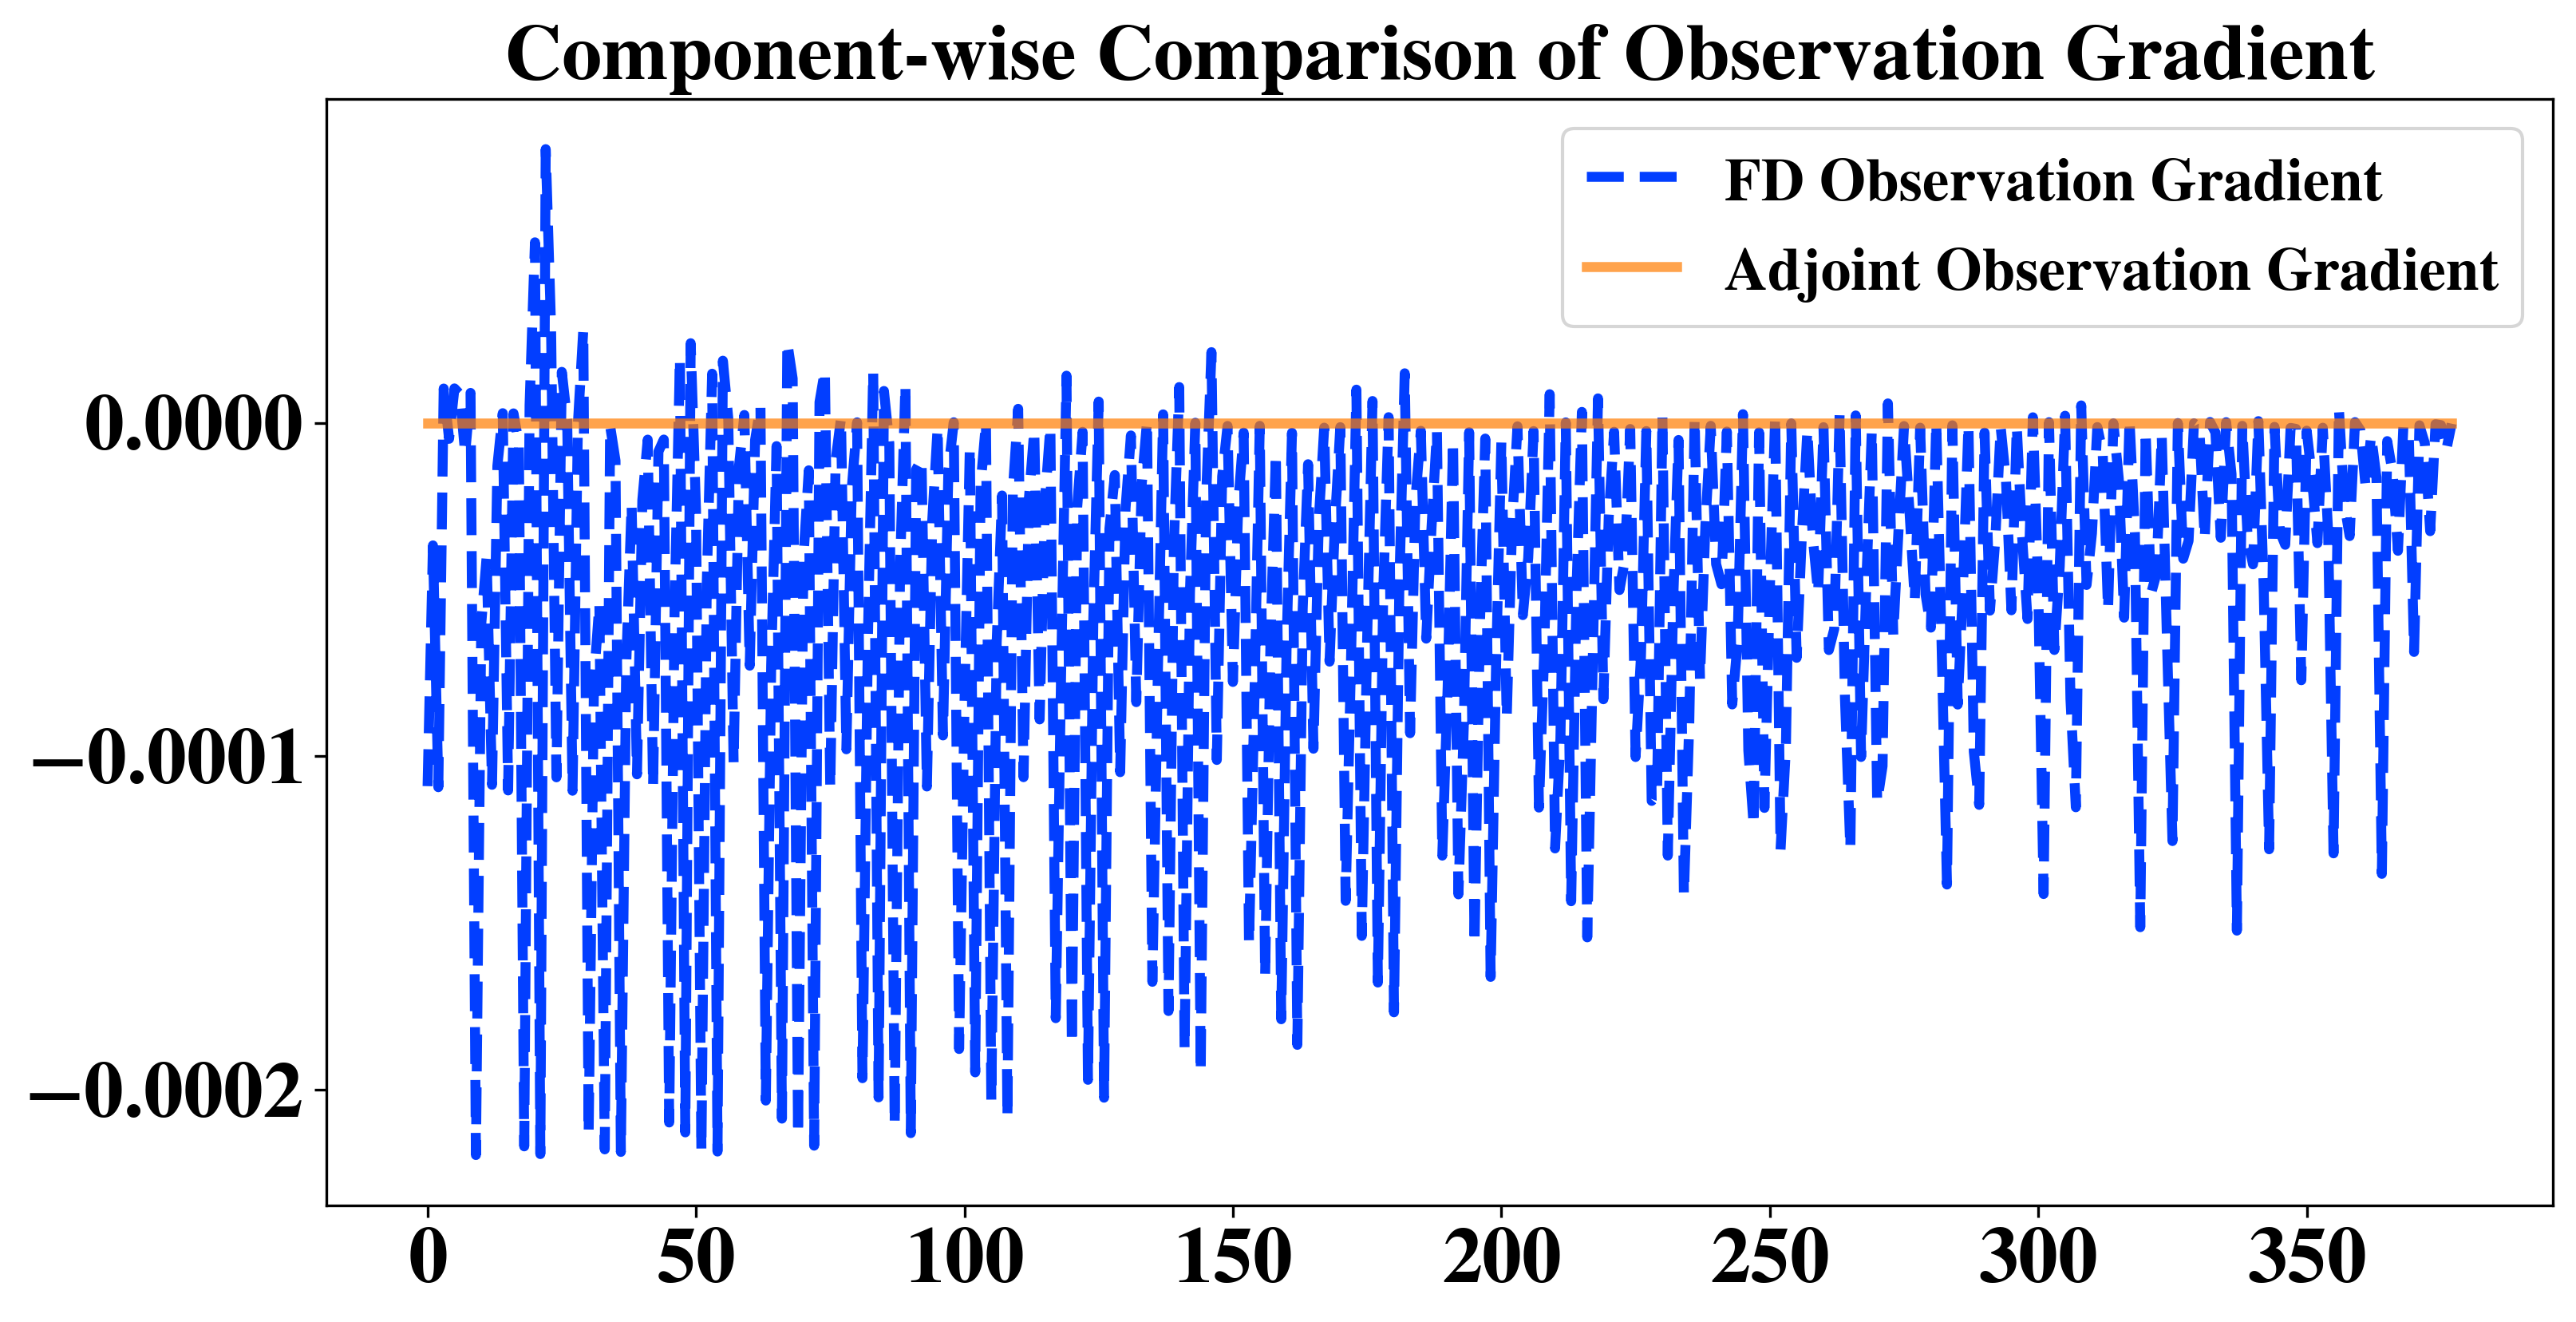

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(grad_observation_fd, label="FD Observation Gradient", linestyle="--")
plt.plot(λ0, label="Adjoint Observation Gradient", alpha=0.7)
plt.legend()
plt.title("Component-wise Comparison of Observation Gradient")
plt.show()


In [ ]:
# def grad_fn_approx(x0, epsilon=1e-6):
#     """
#     Compute the gradient of the cost function using finite differences.
#     """
#     # Using central finite differences
#     grad = np.zeros_like(x0)
    
#     for i in range(len(x0)):
#         x_plus = x0.copy()
#         x_minus = x0.copy()
        
#         x_plus[i] += epsilon
#         x_minus[i] -= epsilon
        
#         J_plus = cost_fn(x_plus)
#         J_minus = cost_fn(x_minus)
        
#         grad[i] = (J_plus - J_minus) / (2 * epsilon)
    
#     return grad




In [12]:
grad_at_init = grad_fn(z0)
# print(f"Gradient at initial state: {grad_at_init}")

Running Gradient for time 0 with adjoint type bayes


Generate a curve showing:

$$
\alpha \mapsto \mathcal{J}\left(z_0+\alpha \cdot d\right)
$$


This visualizes the univariate restriction of the cost function along the descent direction.

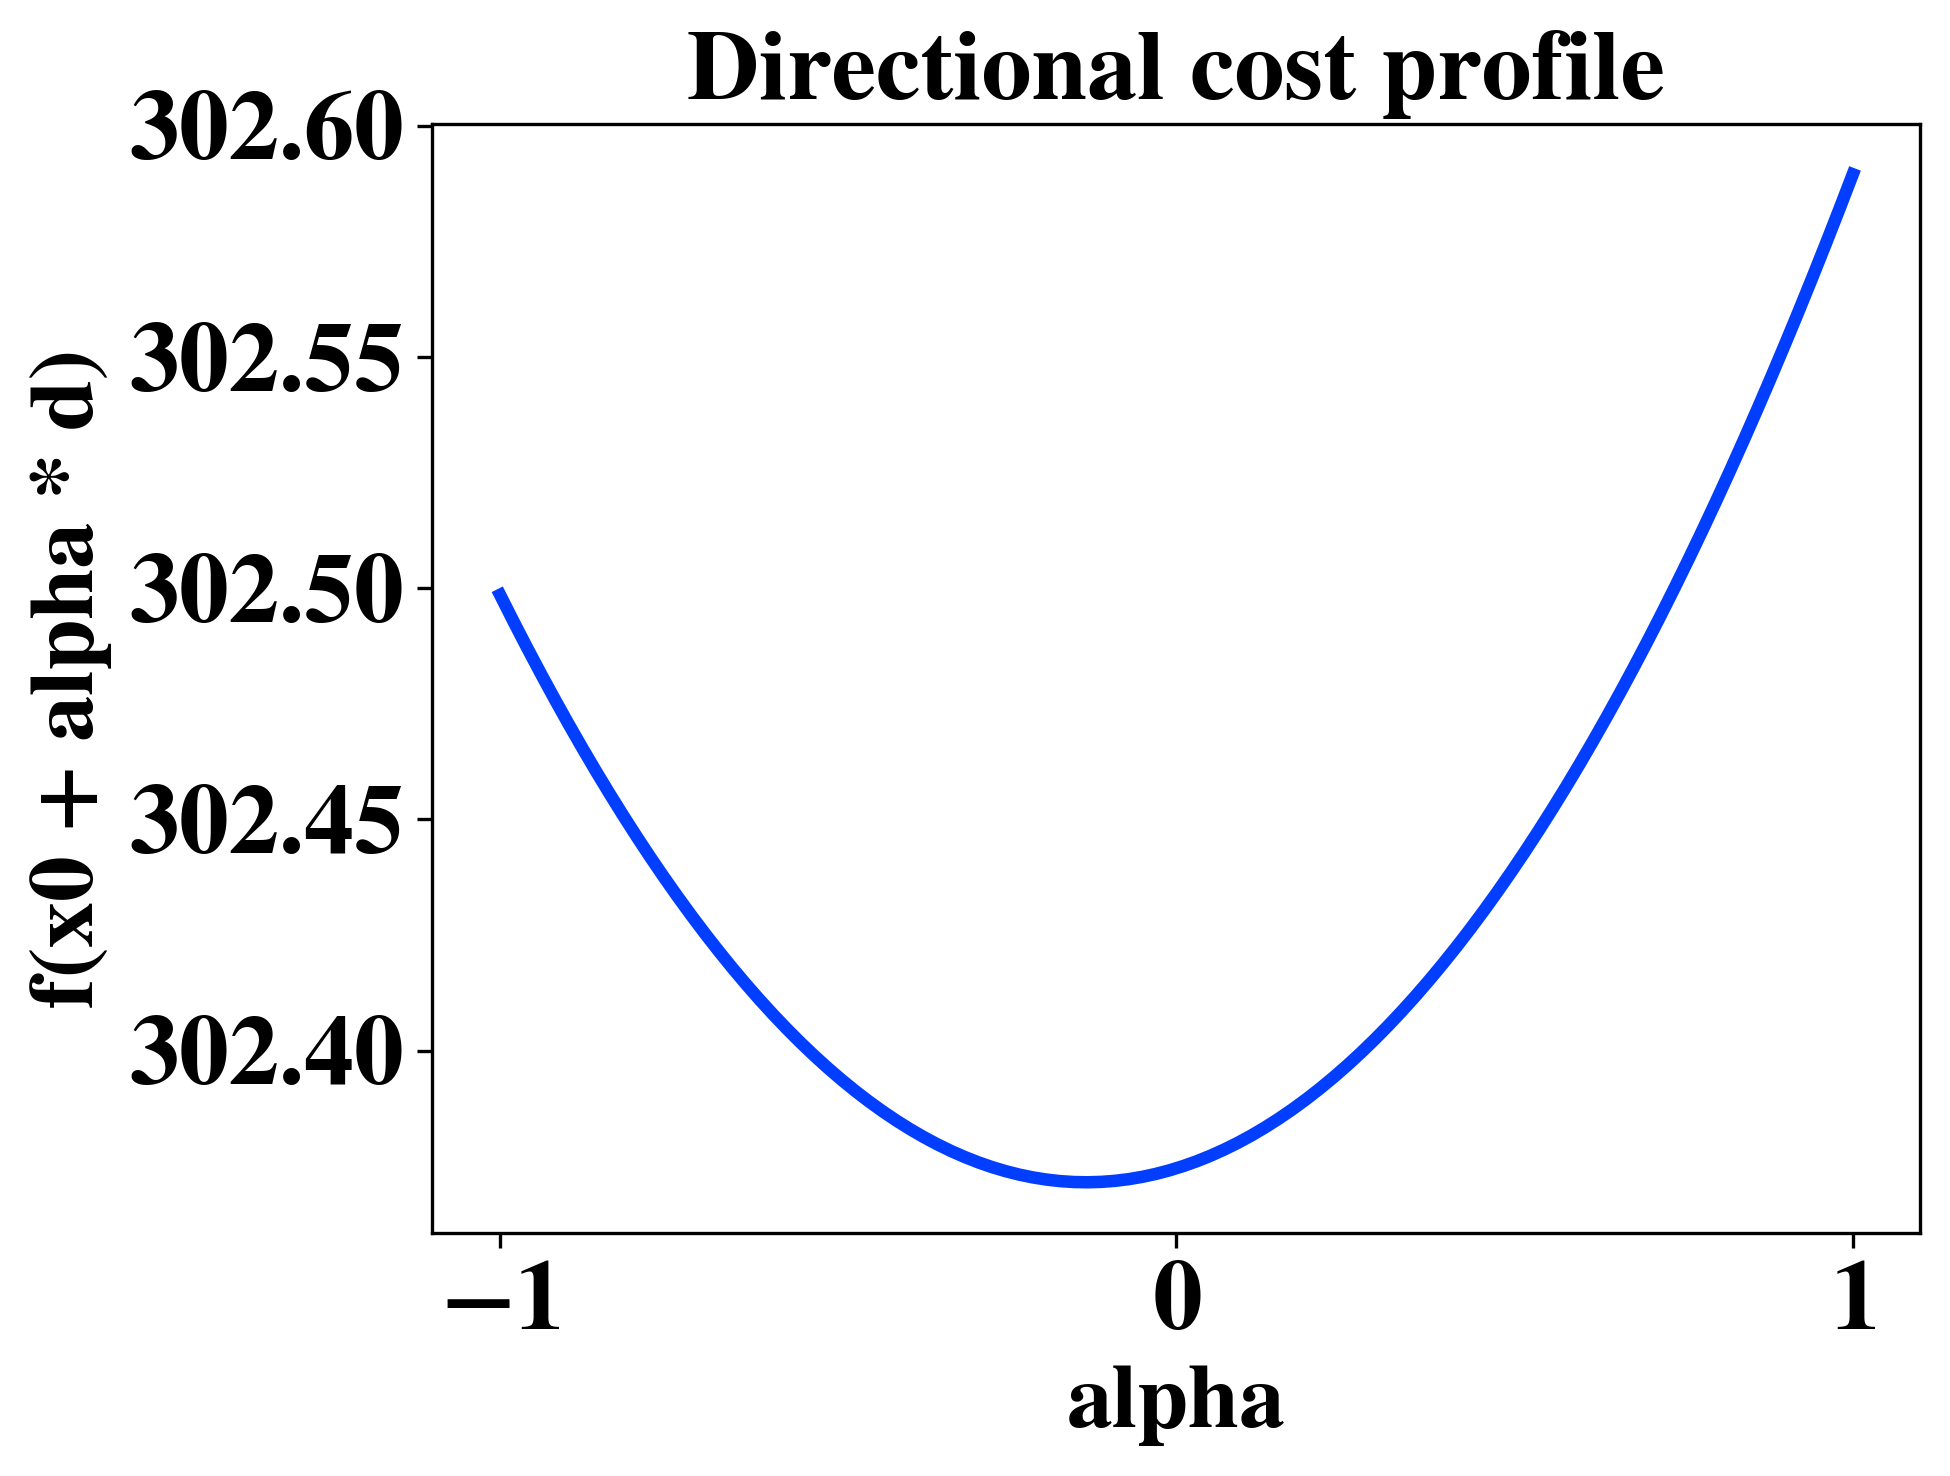

In [ ]:
# Perform line search to find the optimal step size in the direction of the gradient
grad_at_init = grad_fn(z0)
direction = -grad_at_init / np.linalg.norm(grad_at_init) # Normalize the steepest descent direction i.e. the negative gradient direction
alphas = np.linspace(-1, 1, 100) # step size for line search
vals = []


# Evaluate the cost function along the line search direction
for alpha in tqdm(alphas, desc="Line search", unit="α"):
    z = z0 + alpha * direction
    cost = cost_fn(z)
    vals.append(cost)

    # print(f"Alpha: {alpha}, Cost: {cost}")


plt.plot(alphas, vals)
plt.xlabel("alpha")
plt.ylabel("f(x0 + alpha * d)")
plt.title("Directional cost profile")
plt.show()

In [9]:
# get adjoint version of gradient
grad_at_init_adj = grad_fn(z0)
print(f"Adjoint Gradient at initial state: {grad_at_init_adj}")

Adjoint Gradient at initial state: [ 5.24777408e-04  5.49585253e-03 -9.34287740e-03 -2.81421244e-02
 -2.44020476e-02  1.13061790e-01  9.22703382e-02 -2.93715766e-02
 -2.13134303e-02 -3.17196026e-03  7.37755030e-03  1.50576535e-03
  1.56223039e-03  3.86869898e-03  5.75372969e-03 -7.35984254e-03
  8.14128056e-03  8.36164335e-03 -3.46904296e-03 -9.77964105e-03
 -5.68091222e-03 -1.19331217e-03 -7.84403988e-03 -1.16295921e-02
  5.55405472e-03 -6.60349251e-03 -1.00045624e-03 -1.41581579e-02
  1.58381776e-05 -1.70356456e-03 -1.77123330e-03  1.17995171e-02
  2.15246660e-02  5.82437652e-04  9.69435292e-03  4.39680969e-03
 -5.08443587e-03  2.71294111e-02  7.73320079e-03  1.42546610e-03
  2.73154762e-02 -8.25793254e-04 -7.74915432e-04 -2.04324071e-03
  2.07585540e-02 -1.55735054e-03  8.89756263e-03  6.63916951e-04
  2.10813848e-03 -1.84871901e-02  7.45610971e-03 -9.87640167e-03
  1.08462412e-02 -1.30043645e-02 -7.25585543e-03 -3.66190421e-02
 -1.33292349e-02  3.83382811e-03  1.94152732e-02 -2.490

In [7]:
epsilon = np.sqrt(np.finfo(float).eps)  # ≈ 1.49e-8
grad_numerical = approx_fprime(z0, cost_fn, epsilon)

In [11]:
grad_numerical.shape

(378,)

In [12]:
error = np.linalg.norm(grad_at_init_adj - grad_numerical)
rel_error = error / (np.linalg.norm(grad_numerical) + 1e-12)

print("Gradient error:", error)
print("Relative error:", rel_error)

Gradient error: 11.226544752428305
Relative error: 1.0005387292221684


In [8]:
check_grad_result = check_grad(cost_fn, grad_fn, z0)
check_grad_result

np.float64(10.634067143439792)